In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cd drive/MyDrive/

/content/drive/MyDrive


In [ ]:
df = pd.read_csv('Smart-Warehouse-Delay/data/train_v2.csv')
df

,ID,layout_id,scenario_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,...,pack_station_count,charger_count,layout_compactness,zone_dispersion,robot_total,building_age_years,floor_area_sqm,ceiling_height_m,fire_sprinkler_count,emergency_exit_count
0,TRAIN_000000,WH_136,SC_07598,51.0,96.0,3.29,0.1176,0.1765,0.0392,0.3063,...,10.0,5.0,0.4276,0.2536,30,7,5961,6.0,56,4
1,TRAIN_000001,WH_136,SC_07598,NaN,93.0,2.55,0.0597,NaN,0.0149,NaN,...,10.0,5.0,0.4276,0.2536,30,7,5961,6.0,56,4
2,TRAIN_000002,WH_136,SC_07598,92.0,115.0,2.49,0.0652,0.2283,0.0217,0.3063,...,10.0,5.0,0.4276,0.2536,30,7,5961,6.0,56,4
3,TRAIN_000003,WH_136,SC_07598,77.0,110.0,2.52,0.0649,NaN,0.0390,0.3063,...,10.0,5.0,0.4276,0.2536,30,7,5961,6.0,56,4
4,TRAIN_000004,WH_136,SC_07598,NaN,122.0,3.12,0.0667,0.3333,NaN,0.3063,...,10.0,5.0,0.4276,0.2536,30,7,5961,6.0,56,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,TRAIN_249995,WH_174,SC_05114,39.0,NaN,2.28,0.0513,0.1795,NaN,NaN,...,11.0,9.0,0.7086,0.7639,78,48,8140,7.5,15,8
249996,TRAIN_249996,WH_174,SC_05114,69.0,96.0,2.22,0.0870,0.2319,0.0290,0.2226,...,11.0,9.0,0.7086,0.7639,78,48,8140,7.5,15,8
249997,TRAIN_249997,WH_174,SC_05114,61.0,123.0,2.62,0.0984,0.3934,0.0820,0.2226,...,11.0,9.0,0.7086,0.7639,78,48,8140,7.5,15,8
249998,TRAIN_249998,WH_174,SC_05114,54.0,97.0,2.65,0.1296,0.1667,0.0185,0.2226,...,11.0,9.0,0.7086,0.7639,78,48,8140,7.5,15,8


#
### **🔋 3. 배터리 & 충전 (Battery)**
* battery_mean → 평균 배터리 잔량
* battery_std → 배터리 잔량 편차
* low_battery_ratio → 배터리 부족 로봇 비율
* charge_queue_length → 충전 대기 줄 길이
* avg_charge_wait → 평균 충전 대기 시간
* charge_efficiency_pct → 충전 효율
* battery_cycle_count_avg → 평균 충전 사이클 수

layout_info.csv
* charger_count → 충전기 개수

In [ ]:
battery = df[["battery_mean","battery_std","low_battery_ratio",
        "charge_queue_length","avg_charge_wait","charge_efficiency_pct",
        "battery_cycle_count_avg","charger_count"]]
battery

,battery_mean,battery_std,low_battery_ratio,charge_queue_length,avg_charge_wait,charge_efficiency_pct,battery_cycle_count_avg,charger_count
0,70.58,NaN,0.0,0.0,0.0,93.0,201.0,5.0
1,69.87,17.60,0.0,0.0,NaN,90.8,247.0,5.0
2,69.15,17.60,NaN,0.0,0.0,88.1,226.0,5.0
3,68.43,17.60,0.0,0.0,0.0,91.6,NaN,5.0
4,67.71,17.60,0.0,0.0,0.0,90.4,205.0,5.0
...,...,...,...,...,...,...,...,...
249995,59.28,17.76,0.0,0.0,0.0,83.8,233.0,9.0
249996,58.78,17.76,NaN,0.0,0.0,84.0,297.0,9.0
249997,58.27,17.76,0.0,0.0,0.0,NaN,238.0,9.0
249998,NaN,17.76,0.0,0.0,0.0,86.5,311.0,9.0


In [ ]:
battery.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   battery_mean             219680 non-null  float64
 1   battery_std              220621 non-null  float64
 2   low_battery_ratio        220596 non-null  float64
 3   charge_queue_length      220450 non-null  float64
 4   avg_charge_wait          219304 non-null  float64
 5   charge_efficiency_pct    219948 non-null  float64
 6   battery_cycle_count_avg  220045 non-null  float64
 7   charger_count            250000 non-null  float64
dtypes: float64(8)
memory usage: 15.3 MB


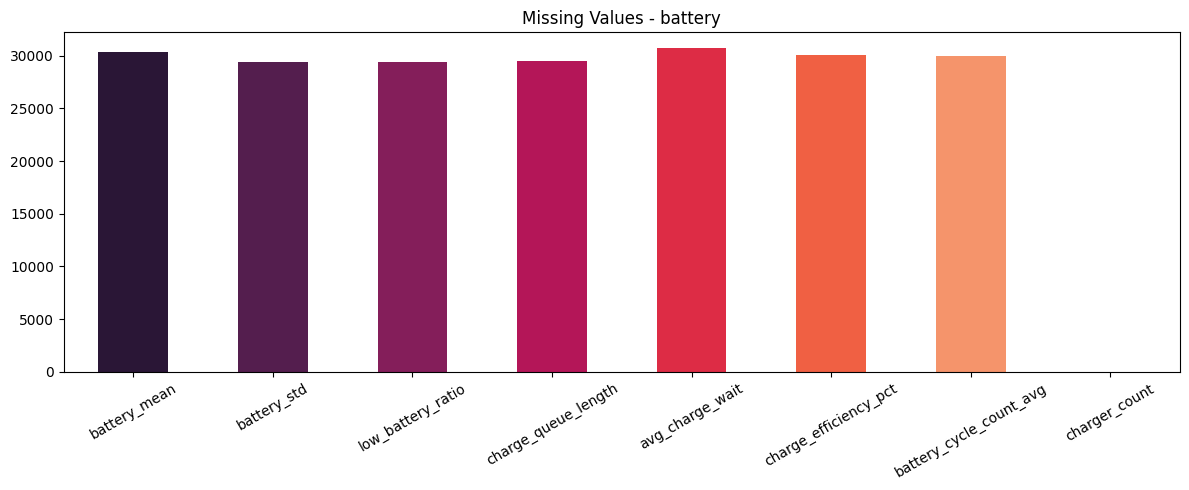

In [ ]:
missing = battery.isnull().sum()

colors = sns.color_palette("rocket", len(missing))

plt.figure(figsize=(12, 5))
missing.plot(kind='bar', color=colors)

plt.title('Missing Values - battery')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#
### **상관관계 분석**
#### **🔋 1) 배터리 상태 vs 고갈 상태**
🔥 가장 중요한 관계  
battery_mean ↔ low_battery_ratio = **-0.93** (매우 강함)

- 배터리 평균 낮아질수록 → 저배터리 로봇 비율 급증
- 거의 동일한 정보 수준 (반대 방향)

📌 결론: 둘 중 하나는 중복 가능성 매우 높음
####
#### **🚨 2) 배터리 고갈 ↔ 충전 병목**
low_battery_ratio ↔ charge_queue_length = **0.79**  
low_battery_ratio ↔ avg_charge_wait = **0.78**

- 배터리 부족 많아짐 → 충전 줄 길어짐
- 충전 대기 시간 증가

📌 의미: 배터리 고갈 = 충전 병목 발생
####
#### **⏳ 3) 충전 병목 내부 구조**
charge_queue_length ↔ avg_charge_wait = **0.86** (매우 강함)

- 충전 대기 줄 길면 → 대기 시간도 자동 증가
- 거의 같은 개념 수준

📌 결론: 둘 중 하나는 줄여도 될 정도로 중복

In [ ]:
corr = battery.corr()
corr

,battery_mean,battery_std,low_battery_ratio,charge_queue_length,avg_charge_wait,charge_efficiency_pct,battery_cycle_count_avg,charger_count
battery_mean,1.000000,-0.530559,-0.933971,-0.720402,-0.714075,0.400234,-0.323042,0.122463
battery_std,-0.530559,1.000000,0.629518,0.563213,0.455589,-0.212473,0.250973,0.028603
low_battery_ratio,-0.933971,0.629518,1.000000,0.794664,0.776675,-0.375327,0.356708,-0.121933
charge_queue_length,-0.720402,0.563213,0.794664,1.000000,0.856635,-0.290978,0.455280,-0.145337
avg_charge_wait,-0.714075,0.455589,0.776675,0.856635,1.000000,-0.286983,0.386328,-0.272505
charge_efficiency_pct,0.400234,-0.212473,-0.375327,-0.290978,-0.286983,1.000000,-0.133462,0.036812
battery_cycle_count_avg,-0.323042,0.250973,0.356708,0.455280,0.386328,-0.133462,1.000000,-0.073762
charger_count,0.122463,0.028603,-0.121933,-0.145337,-0.272505,0.036812,-0.073762,1.000000


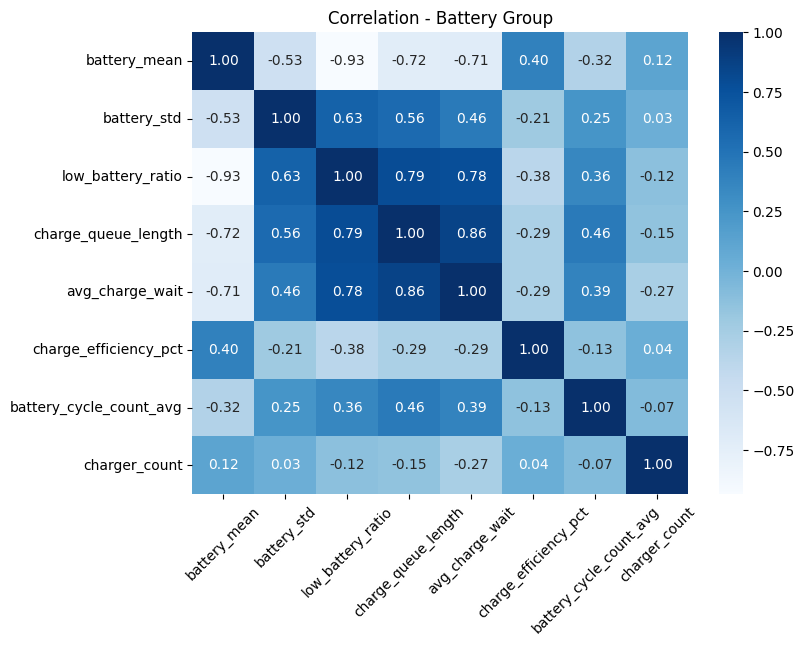

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")

plt.title('Correlation - Battery Group')
plt.xticks(rotation=45)
plt.show()

###
### **결측치 채우기**
#### train datasets
① battery_mean ↔ low_battery_ratio = **-0.93**

In [ ]:
battery[["battery_mean", "low_battery_ratio"]]

,battery_mean,low_battery_ratio
0,70.58,0.0
1,69.87,0.0
2,69.15,NaN
3,68.43,0.0
4,67.71,0.0
...,...,...
249995,59.28,0.0
249996,58.78,NaN
249997,58.27,0.0
249998,NaN,0.0


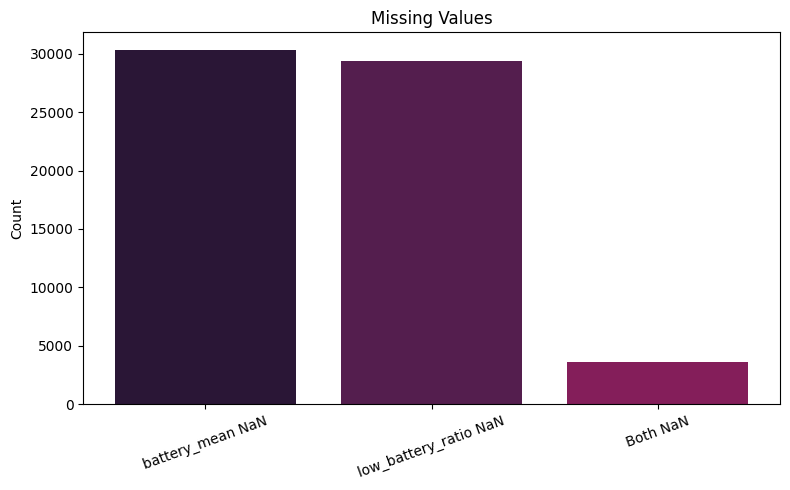

In [ ]:
# 각각 결측치 개수
battery_mean_na = battery["battery_mean"].isnull().sum()
low_ratio_na = battery["low_battery_ratio"].isnull().sum()

# 둘 다 결측치인 경우
both_na = battery[
    battery["battery_mean"].isnull() &
    battery["low_battery_ratio"].isnull()
].shape[0]

nan_counts = {
    'battery_mean NaN': battery_mean_na,
    'low_battery_ratio NaN': low_ratio_na,
    'Both NaN': both_na
}

plt.figure(figsize=(8,5))
plt.bar(nan_counts.keys(), nan_counts.values(), color=colors)

plt.title('Missing Values')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

#####
* low_battery_ratio 기준 결측치 **"battery_mean"** 채우기

In [ ]:
battery["battery_mean"] = battery["battery_mean"].fillna(
    (1 - battery["low_battery_ratio"]) * 100
)

In [ ]:
cols = ["battery_mean", "low_battery_ratio"]

nan_df = battery[cols].isna().sum().to_frame("Missing Values")

nan_df["Both Missing"] = (
    battery["battery_mean"].isna() &
    battery["low_battery_ratio"].isna()
).sum()

nan_df

,Missing Values,Both Missing
battery_mean,3638,3638
low_battery_ratio,29404,3638


#####
* battery_mean 기준 결측치 **"low_battery_ratio"** 채우기

In [ ]:
battery["low_battery_ratio"] = battery["low_battery_ratio"].fillna(
    1 - (battery["battery_mean"] / 100)
)

In [ ]:
cols = ["battery_mean", "low_battery_ratio"]

nan_df = battery[cols].isna().sum().to_frame("Missing Values")

nan_df["Both Missing"] = (
    battery["battery_mean"].isna() &
    battery["low_battery_ratio"].isna()
).sum()

nan_df

,Missing Values,Both Missing
battery_mean,3638,3638
low_battery_ratio,3638,3638


* 저장

In [ ]:
df["battery_mean"] = battery["battery_mean"]
df["low_battery_ratio"] = battery["low_battery_ratio"]

In [ ]:
df[["battery_mean", "low_battery_ratio"]].isnull().sum().to_frame(name="NaN")

,NaN
battery_mean,3638
low_battery_ratio,3638


In [ ]:
# df.to_csv("battery_V2.csv", index=False)

###
② charge_queue_length ↔ avg_charge_wait = **0.86**

In [ ]:
battery[["avg_charge_wait", "charge_queue_length"]]

,avg_charge_wait,charge_queue_length
0,0.0,0.0
1,NaN,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
...,...,...
249995,0.0,0.0
249996,0.0,0.0
249997,0.0,0.0
249998,0.0,0.0


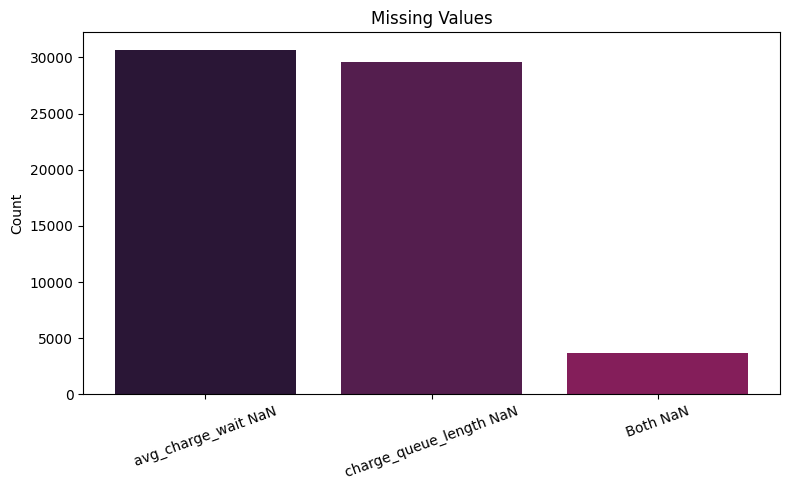

In [ ]:
# 각각 결측치 개수
wait_na = battery["avg_charge_wait"].isnull().sum()
queue_na = battery["charge_queue_length"].isnull().sum()

# 둘 다 결측치인 경우
both_na = battery[
    battery["avg_charge_wait"].isnull() &
    battery["charge_queue_length"].isnull()
].shape[0]

nan_counts = {
    "avg_charge_wait NaN": wait_na,
    "charge_queue_length NaN": queue_na,
    "Both NaN": both_na
}

plt.figure(figsize=(8,5))
plt.bar(nan_counts.keys(), nan_counts.values(), color=colors)

plt.title("Missing Values")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

#####
* charge_queue_length 기준 결측치 **"avg_charge_wait"** 채우기

In [ ]:
battery["avg_charge_wait"] = battery["avg_charge_wait"].fillna(
    battery["charge_queue_length"]
)

In [ ]:
cols = ["avg_charge_wait", "charge_queue_length"]

nan_df = battery[cols].isna().sum().to_frame("Missing Values")

nan_df["Both Missing"] = (
    battery["avg_charge_wait"].isna() &
    battery["charge_queue_length"].isna()
).sum()

nan_df

,Missing Values,Both Missing
avg_charge_wait,3670,3670
charge_queue_length,29550,3670


#####
* avg_charge_wait 기준 결측치 **"charge_queue_length"** 채우기

In [ ]:
battery["charge_queue_length"] = battery["charge_queue_length"].fillna(
    battery["avg_charge_wait"]
)

In [ ]:
cols = ["avg_charge_wait", "charge_queue_length"]

nan_df = battery[cols].isna().sum().to_frame("Missing Values")

nan_df["Both Missing"] = (
    battery["avg_charge_wait"].isna() &
    battery["charge_queue_length"].isna()
).sum()

nan_df

,Missing Values,Both Missing
avg_charge_wait,3670,3670
charge_queue_length,3670,3670


* 저장

In [ ]:
df["avg_charge_wait"] = battery["avg_charge_wait"]
df["charge_queue_length"] = battery["charge_queue_length"]

In [ ]:
df[["avg_charge_wait", "charge_queue_length"]].isnull().sum().to_frame(name="NaN")

,NaN
avg_charge_wait,3670
charge_queue_length,3670


In [ ]:
# df.to_csv("battery_V3.csv", index=False)

###
③ low_battery_ratio ↔ charge_queue_length = **0.79**  
low_battery_ratio ↔ avg_charge_wait = **0.78**

In [ ]:
battery[["low_battery_ratio", "avg_charge_wait","charge_queue_length"]]

,low_battery_ratio,avg_charge_wait,charge_queue_length
0,0.0000,0.0,0.0
1,0.0000,0.0,0.0
2,0.3085,0.0,0.0
3,0.0000,0.0,0.0
4,0.0000,0.0,0.0
...,...,...,...
249995,0.0000,0.0,0.0
249996,0.4122,0.0,0.0
249997,0.0000,0.0,0.0
249998,0.0000,0.0,0.0


In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

cols = ["low_battery_ratio", "charge_queue_length", "avg_charge_wait"]

# 스케일링
scaler = StandardScaler()
scaled_data = scaler.fit_transform(battery[cols])

# KNN Imputer 적용
imputer = KNNImputer(n_neighbors=5)
imputed_data = imputer.fit_transform(scaled_data)

# 원래 스케일로 복원
battery_imputed = pd.DataFrame(
    scaler.inverse_transform(imputed_data),
    columns=cols,
    index=battery.index
)

# 원본 데이터에 반영
battery[cols] = battery_imputed

In [ ]:
df["low_battery_ratio"] = battery["low_battery_ratio"]
df["charge_queue_length"] = battery["charge_queue_length"]
df["avg_charge_wait"] = battery["avg_charge_wait"]

In [ ]:
df[["low_battery_ratio", "avg_charge_wait", "charge_queue_length"]].isnull().sum().to_frame(name="NaN")

,NaN
low_battery_ratio,0
avg_charge_wait,0
charge_queue_length,0


In [ ]:
# df.to_csv("battery_V5.csv", index=False)

#####
* battery_V5에 layout_info 컬럼들 추가

In [ ]:
_battery = pd.read_csv('Smart-Warehouse-Delay/data/battery_V5.csv')
_battery

,ID,layout_id,scenario_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,...,racking_height_avg_m,cross_dock_ratio,packaging_material_cost,quality_check_rate,outbound_truck_wait_min,dock_to_stock_hours,kpi_otd_pct,backorder_ratio,shift_handover_delay_min,sort_accuracy_pct
0,TRAIN_000000,WH_136,SC_07598,51.0,96.0,3.29,0.1176,0.1765,0.0392,0.3063,...,NaN,NaN,4.60,0.1443,8.1,7.92,86.6,0.0787,5.12,NaN
1,TRAIN_000001,WH_136,SC_07598,NaN,93.0,2.55,0.0597,NaN,0.0149,NaN,...,2.50,0.2490,5.22,0.1400,NaN,5.48,83.9,0.0850,5.77,94.88
2,TRAIN_000002,WH_136,SC_07598,92.0,115.0,2.49,0.0652,0.2283,0.0217,0.3063,...,3.87,0.1977,4.26,0.1817,10.7,6.88,82.1,0.1052,NaN,94.40
3,TRAIN_000003,WH_136,SC_07598,77.0,110.0,2.52,0.0649,NaN,0.0390,0.3063,...,2.50,0.1955,4.89,0.1485,10.7,6.76,87.9,0.0920,4.53,93.72
4,TRAIN_000004,WH_136,SC_07598,NaN,122.0,3.12,0.0667,0.3333,NaN,0.3063,...,NaN,0.2351,5.16,0.1514,12.4,9.03,83.8,0.0843,3.99,95.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,TRAIN_249995,WH_174,SC_05114,39.0,NaN,2.28,0.0513,0.1795,NaN,NaN,...,8.10,0.2586,4.17,0.0856,16.0,9.47,99.0,NaN,4.47,97.13
249996,TRAIN_249996,WH_174,SC_05114,69.0,96.0,2.22,0.0870,0.2319,0.0290,0.2226,...,8.63,0.2783,5.61,0.0526,19.6,11.41,NaN,0.0438,NaN,96.73
249997,TRAIN_249997,WH_174,SC_05114,61.0,123.0,2.62,0.0984,0.3934,0.0820,0.2226,...,NaN,0.2659,4.94,0.0379,16.5,13.26,95.9,NaN,3.24,98.86
249998,TRAIN_249998,WH_174,SC_05114,54.0,97.0,2.65,0.1296,0.1667,0.0185,0.2226,...,9.39,0.1736,4.40,0.0320,20.2,11.04,98.7,0.0519,1.97,98.63


In [ ]:
layout = pd.read_csv('Smart-Warehouse-Delay/data/layout_info.csv')
layout

,layout_id,layout_type,aisle_width_avg,intersection_count,one_way_ratio,pack_station_count,charger_count,layout_compactness,zone_dispersion,robot_total,building_age_years,floor_area_sqm,ceiling_height_m,fire_sprinkler_count,emergency_exit_count
0,WH_001,narrow,2.08,34.0,0.3874,9.0,8.0,0.8078,0.5867,21,20,3384,9.4,36,5
1,WH_002,grid,3.70,16.0,0.0054,9.0,11.0,0.7339,0.4390,57,26,8311,8.1,12,2
2,WH_003,grid,2.54,52.0,0.0229,5.0,3.0,0.5498,0.3708,63,39,9465,7.2,81,2
3,WH_004,hybrid,3.37,35.0,0.4836,5.0,10.0,0.4821,0.5661,100,40,7918,12.7,26,5
4,WH_005,grid,3.68,48.0,0.0494,8.0,13.0,0.6740,0.9970,50,33,5905,5.6,84,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,WH_296,grid,3.26,45.0,0.2777,7.0,7.0,0.7694,0.7045,19,35,4080,10.9,22,9
296,WH_297,hybrid,2.14,25.0,0.1410,19.0,15.0,0.5534,0.1224,30,20,8782,12.2,58,2
297,WH_298,hub_spoke,3.74,10.0,0.0107,4.0,10.0,0.3098,0.4970,26,17,6635,9.6,91,6
298,WH_299,narrow,1.70,15.0,0.6002,9.0,15.0,0.8984,0.9239,58,33,3744,14.7,83,3


In [ ]:
# layout_id 기준으로 병합
_battery = _battery.merge(layout, on="layout_id", how="left")

In [ ]:
_battery.to_csv("battery_V6.csv", index=False)